In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load Breast Cancer Dataset
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df['diagnosis'] = df['target'].map({0:'malignant', 1:'benign'})

print("✅ Dataset Loaded!")
print("Shape:", df.shape)
print("\nClass Distribution:")
print(df['diagnosis'].value_counts())
df.head()

✅ Dataset Loaded!
Shape: (569, 32)

Class Distribution:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [12]:
# Features and Target
X = df[cancer.feature_names]
y = df['target']

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Data Preprocessed!")
print("Missing Values:", df.isnull().sum().sum())
print("Features shape:", X.shape)
print("Target shape  :", y.shape)

✅ Data Preprocessed!
Missing Values: 0
Features shape: (569, 30)
Target shape  : (569,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("✅ Train-Test Split Done!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

✅ Train-Test Split Done!
Training samples : 455
Testing  samples : 114


In [14]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

print("✅ Decision Tree Trained!")
print("Max Depth  :", dt_model.get_depth())
print("Num Leaves :", dt_model.get_n_leaves())

✅ Decision Tree Trained!
Max Depth  : 4
Num Leaves : 12


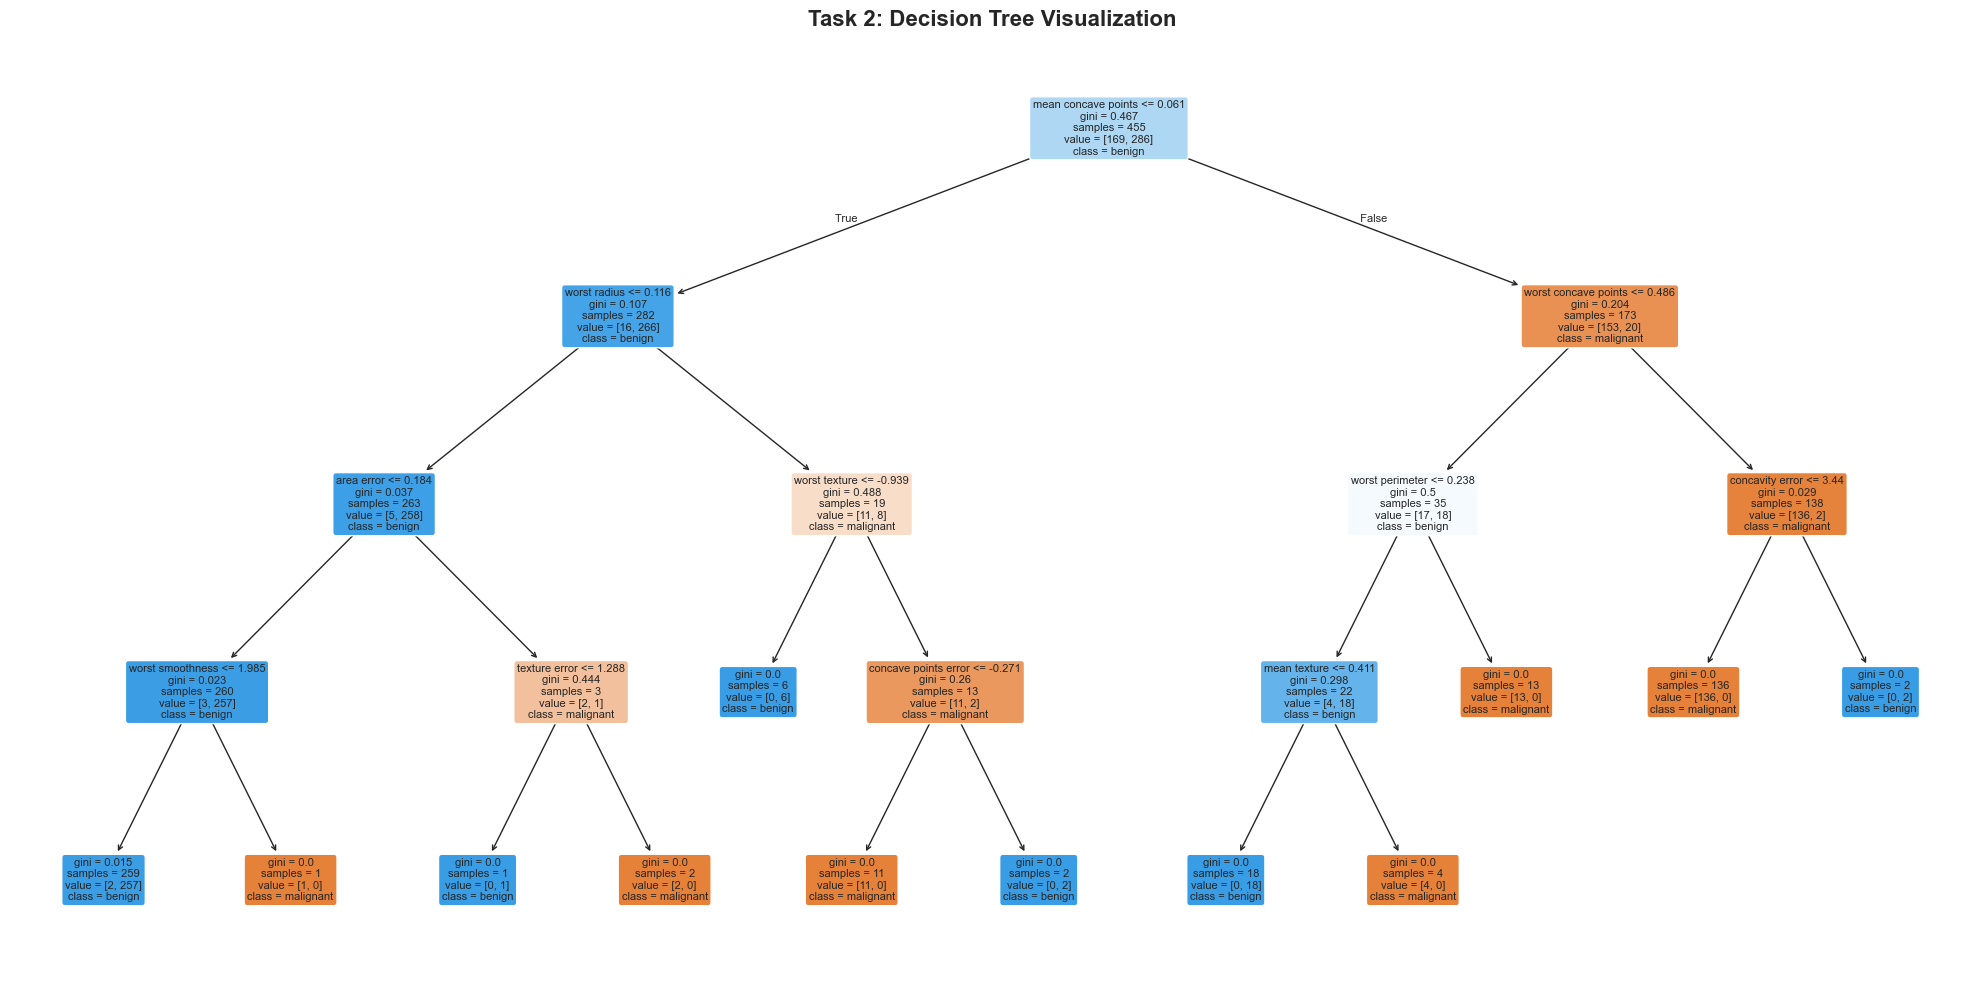

✅ Decision Tree Visualized!


In [15]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model,
          feature_names=cancer.feature_names,
          class_names=['malignant','benign'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Task 2: Decision Tree Visualization',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Decision Tree Visualized!")

   DECISION TREE EVALUATION
✅ Accuracy  : 94.74%
✅ F1 Score  : 0.9577

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



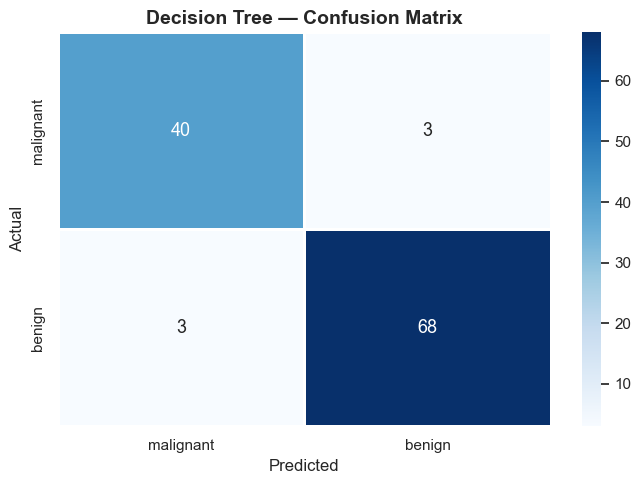

In [16]:
y_pred_dt = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_f1  = f1_score(y_test, y_pred_dt)

print("=" * 45)
print("   DECISION TREE EVALUATION")
print("=" * 45)
print(f"✅ Accuracy  : {dt_acc*100:.2f}%")
print(f"✅ F1 Score  : {dt_f1:.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt,
      target_names=['malignant','benign']))

# Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['malignant','benign'],
            yticklabels=['malignant','benign'],
            linewidths=1, annot_kws={'size':13})
plt.title('Decision Tree — Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)
rf_model.fit(X_train, y_train)

print("✅ Random Forest Trained!")
print("Number of Trees:", rf_model.n_estimators)

✅ Random Forest Trained!
Number of Trees: 100


   RANDOM FOREST EVALUATION
✅ Accuracy  : 96.49%
✅ F1 Score  : 0.9722

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



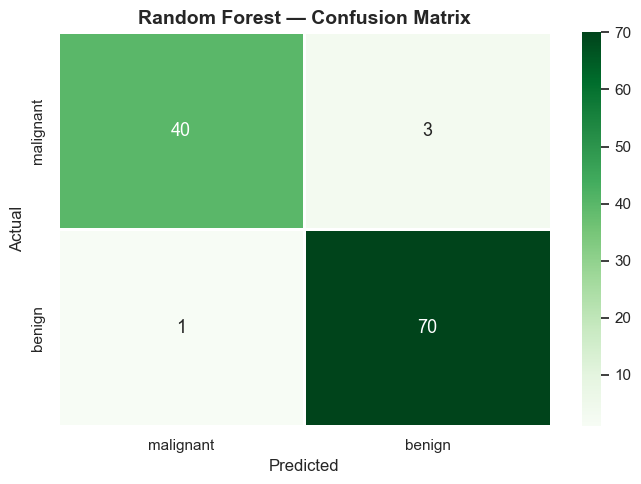

In [18]:
y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1  = f1_score(y_test, y_pred_rf)

print("=" * 45)
print("   RANDOM FOREST EVALUATION")
print("=" * 45)
print(f"✅ Accuracy  : {rf_acc*100:.2f}%")
print(f"✅ F1 Score  : {rf_f1:.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['malignant','benign']))

# Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['malignant','benign'],
            yticklabels=['malignant','benign'],
            linewidths=1, annot_kws={'size':13})
plt.title('Random Forest — Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

      MODEL COMPARISON
Model                       Accuracy   F1 Score
--------------------------------------------------
Decision Tree                 94.74%     0.9577
Random Forest                 96.49%     0.9722
✅ Random Forest performs better!


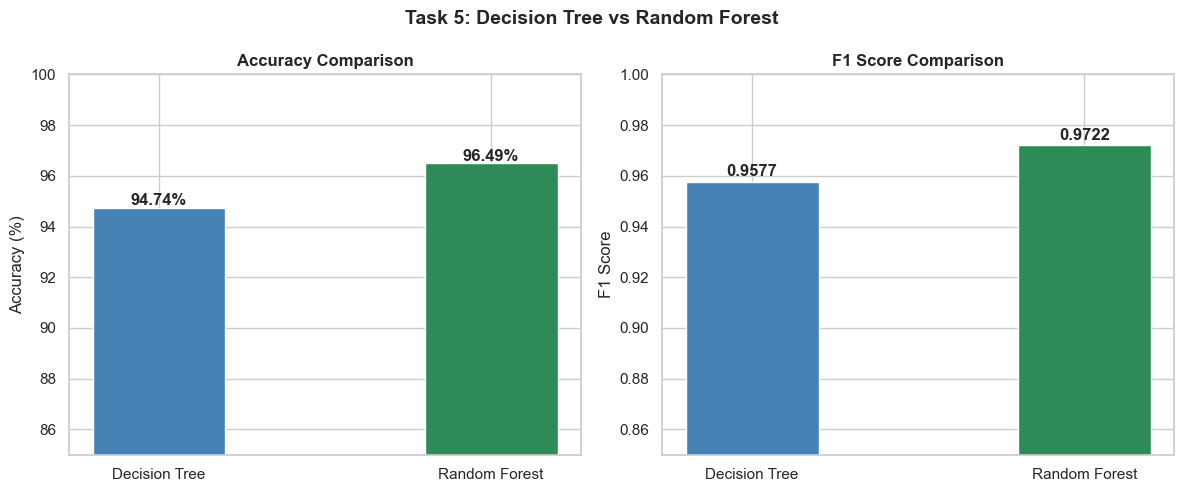

In [19]:
print("=" * 50)
print("      MODEL COMPARISON")
print("=" * 50)
print(f"{'Model':<25} {'Accuracy':>10} {'F1 Score':>10}")
print("-" * 50)
print(f"{'Decision Tree':<25} {dt_acc*100:>9.2f}% {dt_f1:>10.4f}")
print(f"{'Random Forest':<25} {rf_acc*100:>9.2f}% {rf_f1:>10.4f}")
print("=" * 50)
better = "Random Forest" if rf_acc > dt_acc else "Decision Tree"
print(f"✅ {better} performs better!")
print("=" * 50)

# Bar Chart Comparison
models  = ['Decision Tree', 'Random Forest']
acc     = [dt_acc*100, rf_acc*100]
f1      = [dt_f1, rf_f1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(models, acc, color=['steelblue','seagreen'],
            width=0.4, edgecolor='white')
axes[0].set_title('Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(85, 100)
for i, v in enumerate(acc):
    axes[0].text(i, v+0.1, f'{v:.2f}%', ha='center', fontweight='bold')

axes[1].bar(models, f1, color=['steelblue','seagreen'],
            width=0.4, edgecolor='white')
axes[1].set_title('F1 Score Comparison', fontweight='bold')
axes[1].set_ylabel('F1 Score'); axes[1].set_ylim(0.85, 1.0)
for i, v in enumerate(f1):
    axes[1].text(i, v+0.002, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Task 5: Decision Tree vs Random Forest',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

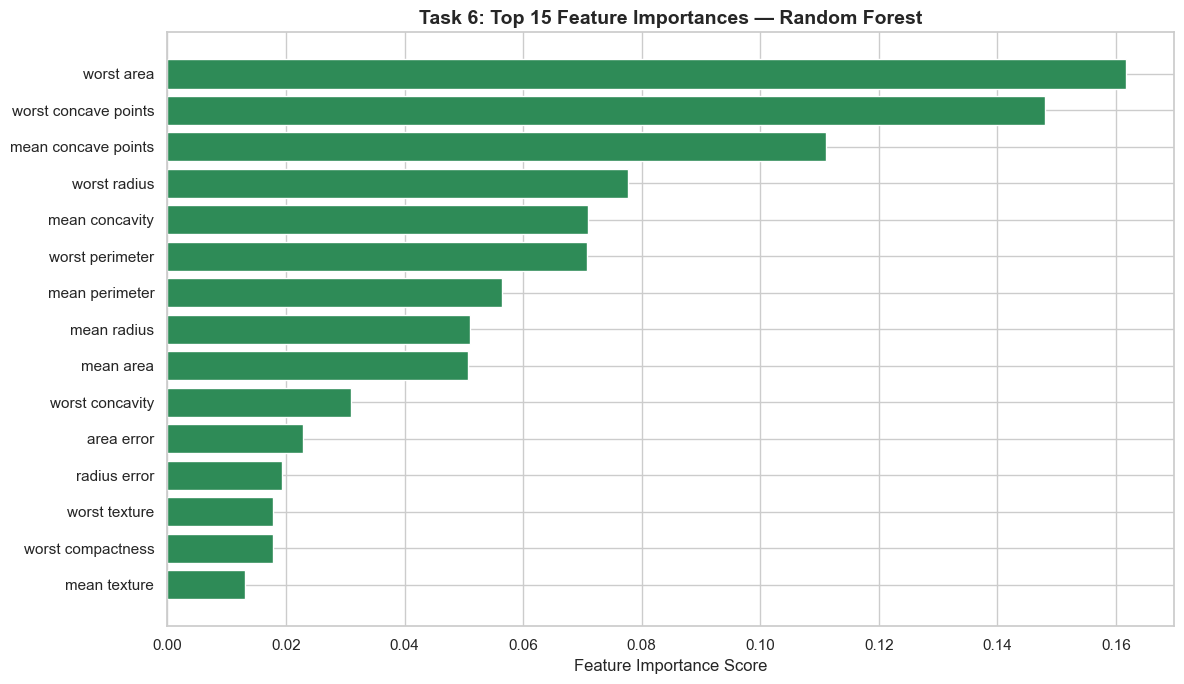

Top 5 Most Important Features:
  1. worst area                          0.1617
  2. worst concave points                0.1481
  3. mean concave points                 0.1111
  4. worst radius                        0.0777
  5. mean concavity                      0.0709


In [20]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]
top_features = [cancer.feature_names[i] for i in indices]
top_importance = importances[indices]

plt.figure(figsize=(12, 7))
plt.barh(top_features[::-1], top_importance[::-1],
         color='seagreen', edgecolor='white')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Task 6: Top 15 Feature Importances — Random Forest',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features:")
for i in range(5):
    print(f"  {i+1}. {top_features[i]:35} {top_importance[i]:.4f}")


INTERVIEW QUESTIONS — ANSWERS
══════════════════════════════════════════════════════

Q1. Tree vs Forest?
    Decision Tree  = Single tree, simple, fast,
                     prone to overfitting
    Random Forest  = Many trees combined (ensemble),
                     more accurate, handles overfitting

Q2. Gini Impurity vs Information Gain?
    Gini Impurity  = Measures how often a randomly chosen
                     element is incorrectly classified
                     Value between 0 (pure) to 0.5 (impure)
    Information Gain = Measures reduction in entropy
                     after splitting on a feature
                     Higher = better split

Q3. How Random Forest handles overfitting?
    1. Uses many trees (100+) instead of one
    2. Each tree trained on random subset of data (Bagging)
    3. Each split uses random subset of features
    4. Final prediction = majority vote of all trees
    5. This reduces variance and prevents overfitting

Q4. What is Bagging?
    Bagging = Bootstrap Aggregating
    Steps:
    1. Create multiple random samples from training data
    2. Train one Decision Tree on each sample
    3. Combine all predictions by voting (classification)
       or averaging (regression)
    Result: More stable and accurate model

══════════════════════════════════════════════════════
